# 04 - SAFE ma-QAOA: Surrogate-Assisted and Fine-Tuning Enhanced multi-angle QAOA

Reference: H. Kim, Y. Lee, "SAFE ma-QAOA: Surrogate-Assisted and Fine-Tuning Enhanced
Multi-Angle QAOA with Parameter Distillation", arXiv:2605.23377.

What this notebook answers:

- What is the **SAFE** workflow, and what does the surrogate buy?
- Stage 1: how to pre-train multi-angle QAOA parameters on a cheap, weight-truncated
  PADO-Pauli surrogate (**LWPP warmup**).
- Stage 2 (optional): **parameter distillation** - dropping near-zero-angle gates.
- Stage 3: **exact fine-tuning** from the warm start, against a statevector.
- How many exact optimization steps the warmup saves on a 16-qubit MaxCut instance.

## Notebook Guide / 노트북 가이드

- **EN** SAFE = LWPP surrogate warmup → (optional) parameter distillation → exact fine-tuning.
- **KO** SAFE = LWPP surrogate 사전학습 → (선택) parameter distillation → exact 미세조정.
- **EN** The two engines differ on purpose: the surrogate is a PADO-Pauli truncated program,
  the reference is an exact PennyLane statevector. Only the surrogate approximates.
- **KO** 두 엔진은 의도적으로 다릅니다: 대리모델은 PADO-Pauli 절단 프로그램, 기준은 정확한
  PennyLane statevector. 근사가 들어가는 쪽은 대리모델뿐입니다.
- **EN** Expected outcome: the exact-only baseline needs more exact steps than SAFE to reach the
  same approximation ratio (the notebook prints how many), and distillation removes part of
  the parameters (the notebook prints the fraction).
- **KO** 기대 결과: exact-only 기준선은 같은 근사비에 도달하는 데 SAFE보다 많은 exact 스텝이 필요하고
  (노트북이 스텝 수를 출력), distillation이 파라미터 일부를 제거합니다 (노트북이 비율을 출력).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pennylane as qml
import torch
import matplotlib.pyplot as plt

import padopauli
from padopauli import Circuit, PauliRotation, CliffordGate

use_cuda = torch.cuda.is_available()
nb_preset = "gpu" if use_cuda else "cpu"
print(f"padopauli {padopauli.__version__}")
print(f"torch {torch.__version__} | pennylane {qml.version()} | cuda available: {use_cuda} | preset: {nb_preset}")

# plot style
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
plt.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

padopauli 2.0.0
torch 2.11.0+rocm7.2 | pennylane 0.45.1 | cuda available: True | preset: gpu


## 1) The problem: a 16-qubit MaxCut instance

An Erdős-Rényi random graph at edge probability 0.3 (as in the SAFE paper, arXiv:2605.23377),
here with n = 16, unweighted, mapped to the Ising cost `H_C = Σ_{(i,j)∈E} Z_i Z_j` (all `J_ij = 1`,
no local fields) - we **minimize** `⟨H_C⟩`. At n = 16 the full spectrum is 65,536 states, so
the exact optimum is available by brute force and we can report the
**approximation ratio** `α = (E_max − E) / (E_max − E_min)` ∈ [0, 1].

In [2]:
n, GRAPH_SEED, P_EDGE = 16, 112203, 0.3
rng = np.random.default_rng(GRAPH_SEED)
edges = [(u, v) for u in range(n) for v in range(u + 1, n) if rng.random() < P_EDGE]
print(f"MaxCut instance: n = {n}, {len(edges)} edges (Erdos-Renyi, p = {P_EDGE}, seed {GRAPH_SEED})")

# Brute force over all 2^16 spin configurations (vectorized)
spins = ((np.arange(2 ** n)[:, None] >> np.arange(n)) & 1) * 2 - 1     # (65536, n) of +-1
energies = np.zeros(2 ** n)
for u, v in edges:
    energies += spins[:, u] * spins[:, v]
E_MIN, E_MAX = float(energies.min()), float(energies.max())
print(f"ground energy E_min = {E_MIN:+.6f}, E_max = {E_MAX:+.6f}")

def alpha(e):
    """Approximation ratio: 1 at the ground state, 0 at the worst state."""
    return (E_MAX - np.asarray(e)) / (E_MAX - E_MIN)

MaxCut instance: n = 16, 33 edges (Erdos-Renyi, p = 0.3, seed 112203)
ground energy E_min = -19.000000, E_max = +33.000000


## 2) The ma-QAOA circuit and observable

Multi-angle QAOA gives **every gate its own angle** (one `param_idx` per gate) instead of one
(γ, β) pair per layer: per layer, |edges| RZZ cost rotations (`qc.rzz`) then n RX mixer
rotations (`qc.rx`). The initial |+⟩^n state is an explicit Hadamard layer (`qc.h`; the
engine starts from |0…0⟩). The cost observable ⟨H_C⟩ is one multi-term observable - a list
of `("ZZ", [u, v], 1.0)` tuples.

In [3]:
P_LAYERS = 2

def build_ma_qaoa(n, edges, p):
    qc = Circuit(n)
    for q in range(n):
        qc.h(q)                                       # |+>^n start
    pidx = 0
    for _ in range(p):
        for (u, v) in edges:
            qc.rzz(u, v, param_idx=pidx); pidx += 1   # one angle per cost gate
        for q in range(n):
            qc.rx(q, param_idx=pidx); pidx += 1       # one angle per mixer gate
    return qc

qc = build_ma_qaoa(n, edges, P_LAYERS)
n_params = qc.n_params
print(f"p = {P_LAYERS}: {len(qc.gates)} gates, {n_params} trainable angles")

obs = [("ZZ", [u, v], 1.0) for (u, v) in edges]        # <H_C> is the loss (one observable)

p = 2: 114 gates, 98 trainable angles


## 3) Initialization

The SAFE paper (arXiv:2605.23377) sweeps eleven initializations per instance; here we fix a
single **constant** start - all cost angles at `+c`, all mixer angles at `−c`, with `c = 0.01` -
so that the comparison below is a single pair of runs rather than an average over restarts.
Both methods start from this same vector.

In [4]:
C_INIT = 0.01

def constant_init(n, edges, p, c):
    th, k = np.zeros(p * (len(edges) + n)), 0
    for _l in range(p):
        th[k:k + len(edges)] = c; k += len(edges)     # cost angles  +c
        th[k:k + n] = -c; k += n                      # mixer angles -c
    return th

theta_init = torch.tensor(constant_init(n, edges, P_LAYERS, C_INIT),
                          dtype=torch.float64).unsqueeze(0)
print(f"constant init c = {C_INIT}: theta shape {tuple(theta_init.shape)}")

constant init c = 0.01: theta shape (1, 98)


## 4) The two engines: cheap surrogate vs exact statevector

- **LWPP (Low-Weight Pauli Propagation)**: the circuit compiled by PADO-Pauli with
  `max_weight=4` - Pauli terms of weight > 4 are dropped during propagation. It runs on the
  preset's device and is differentiable in place.
- **Exact**: a PennyLane `default.qubit` statevector with torch backprop. It stands in for
  the expensive resource (an exact emulator or a QPU).

These are deliberately **two different engines**. Compiling PADO-Pauli without truncation
and optimizing against that would defeat the point of a surrogate: it materializes the very
operator space the surrogate exists to avoid. We do check the two against each other for
gate-convention agreement, using PADO-Pauli's own PennyLane reference path.

In [5]:
# --- the surrogate: a PADO-Pauli truncated program -------------------------
lwpp_program = qc.compile(observables=[obs], preset=nb_preset, dtype="float64", max_weight=4)

lwpp_nnz = sum(int(s.mat_const._nnz()) + int(s.mat_cos._nnz()) + int(s.mat_sin._nnz())
               for s in lwpp_program.psum_union.steps)
print(f"LWPP program: {lwpp_nnz:,} nonzeros over {len(lwpp_program.psum_union.steps)} steps")

# --- the exact reference: a differentiable statevector ---------------------
sv_dev = qml.device("default.qubit", wires=n)
H_C = qml.sum(*[qml.prod(qml.Z(u), qml.Z(v)) for (u, v) in edges])

def make_exact(gates):
    """<H_C> on an exact statevector, for any padopauli gate list (H + PauliRot)."""
    @qml.qnode(sv_dev, interface="torch", diff_method="backprop")
    def node(theta):
        for g in gates:
            if isinstance(g, CliffordGate):
                qml.Hadamard(wires=g.qubits[0])
            else:
                qml.PauliRot(theta[..., int(g.param_idx)], str(g.pauli), wires=list(g.qubits))
        return qml.expval(H_C)
    return node

exact_energy = make_exact(qc.gates)

# Gate-convention check against padopauli's own PennyLane reference path.
from padopauli import pennylane_expvals
row = theta_init[0]
mine = float(exact_energy(row))
ref = float(pennylane_expvals(circuit=qc.gates, observables=lwpp_program.observables,
                                    thetas=row.numpy(), n_qubits=n, max_qubits=20)[0])
print(f"convention check: statevector node {mine:+.10f} vs padopauli reference {ref:+.10f} "
      f"(diff {abs(mine - ref):.2e})")
print(f"alpha at the initialization: {alpha(mine):.4f}")

propagate:   0%|          | 0/114 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 18,136


zero-filter:   0%|          | 0/114 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 335 (1.847155% of peak)
LWPP program: 18,264 nonzeros over 114 steps
convention check: statevector node -0.0197800051 vs padopauli reference -0.0197800051 (diff 3.19e-16)
alpha at the initialization: 0.6350


## 5) Stage 1 - LWPP warmup

Adam on the **surrogate** energy, lr = 0.02, 500 steps, as in the SAFE paper (arXiv:2605.23377). The exact
statevector is not touched at all during this stage.

In [6]:
LR, LWPP_STEPS, EXACT_STEPS, BASE_STEPS = 0.02, 500, 100, 300
dev = "cuda" if use_cuda else "cpu"

def train(energy_fn, theta0, steps):
    theta = torch.nn.Parameter(theta0.clone())
    opt = torch.optim.Adam([theta], lr=LR)
    trace = []
    for _ in range(steps):
        opt.zero_grad(set_to_none=True)
        e = energy_fn(theta)
        e.sum().backward()
        opt.step()
        trace.append(float(e.detach().reshape(-1)[0]))
    return theta.detach(), np.array(trace)

theta_warm, _ = train(lambda t: lwpp_program.expvals(t.to(dev))[:, 0],
                      theta_init.to(dev), LWPP_STEPS)
theta_warm = theta_warm.cpu()

with torch.no_grad():
    a_warm = float(alpha(exact_energy(theta_warm).reshape(-1)[0].item()))
print(f"after {LWPP_STEPS} surrogate steps: exact alpha = {a_warm:.4f} "
      f"- no exact steps spent yet")

after 500 surrogate steps: exact alpha = 0.9550 - no exact steps spent yet


## 6) Stage 3 - exact fine-tuning, vs the exact-only baseline

Both runs use the identical optimizer (Adam, lr = 0.02) and the identical exact statevector;
the only difference is the starting point.

- **SAFE**: start from the warmed-up θ, 100 exact steps.
- **Exact-only baseline**: start from the same raw initialization. We give it 300 steps so we
  can read off how many exact steps it takes to catch up, rather than just capping it at 100.

In [7]:
_, safe_tr = train(exact_energy, theta_warm, EXACT_STEPS)
_, base_tr = train(exact_energy, theta_init, BASE_STEPS)

a_safe, a_base = alpha(safe_tr), alpha(base_tr)
reached = np.flatnonzero(a_base >= a_safe[-1] - 1e-4)
catch_up = int(reached[0]) + 1 if reached.size else None

print(f"SAFE       : alpha = {a_safe[-1]:.4f}  after {EXACT_STEPS} exact steps")
print(f"exact-only : alpha = {a_base[EXACT_STEPS - 1]:.4f}  after {EXACT_STEPS} exact steps")
print(f"exact-only : alpha = {a_base[-1]:.4f}  after {BASE_STEPS} exact steps")
if catch_up:
    print(f"exact-only needs {catch_up} exact steps to match SAFE's {EXACT_STEPS}-step result "
          f"({catch_up / EXACT_STEPS:.1f}x)")
else:
    print(f"exact-only does not match SAFE within {BASE_STEPS} exact steps")

SAFE       : alpha = 0.9615  after 100 exact steps
exact-only : alpha = 0.9399  after 100 exact steps
exact-only : alpha = 0.9615  after 300 exact steps
exact-only needs 155 exact steps to match SAFE's 100-step result (1.6x)


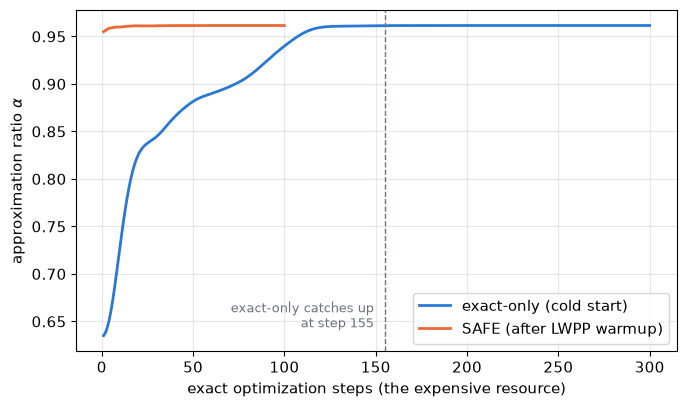

In [8]:
fig, ax = plt.subplots()
ax.plot(range(1, BASE_STEPS + 1), a_base, color=PALETTE[0], lw=2, label="exact-only (cold start)")
ax.plot(range(1, EXACT_STEPS + 1), a_safe, color=PALETTE[1], lw=2, label="SAFE (after LWPP warmup)")
if catch_up:
    ax.axvline(catch_up, color="#6b7280", lw=1, ls="--")
    ax.annotate(f"exact-only catches up\nat step {catch_up}", (catch_up, a_base.min()),
                xytext=(-8, 6), textcoords="offset points", ha="right",
                color="#6b7280", fontsize=9)
ax.set_xlabel("exact optimization steps (the expensive resource)")
ax.set_ylabel(r"approximation ratio $\alpha$")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/fig_SAFE_ma-QAOA_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

The warmup happened entirely on the truncated surrogate, never touching the 2^n statevector, so the SAFE curve starts near the top: most of
the optimization distance was covered before the first expensive step. Note what this does
*not* claim: exact-only is not stuck below SAFE, it is simply slower to get there. The size
of the gap also depends on where the optimizer starts; this is a single initialization, not an
average over the eleven used in the SAFE paper (arXiv:2605.23377).

## 7) Stage 2 - parameter distillation

After the warmup, many multi-angle parameters sit near zero - gates that barely rotate.
**Distillation deletes every rotation with |θ| ≤ 0.3** (the largest of the SAFE paper's
thresholds 0 / 0.01 / 0.3; the largest-|θ| gate is always kept), renumbers the survivors' `param_idx`,
rebuilds the pruned circuit with the `Circuit` builder, and fine-tunes only the remaining
angles. Fewer gates = a shorter circuit on hardware and fewer parameters to optimize.
(`qc.gates` exposes the underlying gate descriptors - `PauliRotation` / `CliffordGate` -
which is all the pruning needs.)

In [9]:
CUT_ANGLE = 0.3
theta_best = theta_warm[0]

def distill(qc, theta, cut):
    keep = {int(theta.abs().argmax())}                           # force-keep the largest
    keep |= {i for i in range(len(theta)) if abs(float(theta[i])) > cut}
    active = sorted(keep)
    remap = {old: new for new, old in enumerate(active)}
    pruned = Circuit(qc.n_qubits)
    for g in qc.gates:
        if isinstance(g, PauliRotation):
            if g.param_idx in remap:
                pruned.rot(g.pauli, list(g.qubits), param_idx=remap[g.param_idx])
        elif isinstance(g, CliffordGate):
            pruned.clifford(g.symbol, list(g.qubits))
    return pruned, theta[active].clone(), active

pruned_qc, theta_active, active = distill(qc, theta_best, CUT_ANGLE)
print(f"distillation: {len(qc.gates)} gates -> {len(pruned_qc.gates)}, "
      f"{n_params} params -> {len(active)} active "
      f"({100 * (1 - len(active) / n_params):.0f}% removed)")

_, dist_tr = train(make_exact(pruned_qc.gates), theta_active.unsqueeze(0), EXACT_STEPS)
a_dist = alpha(dist_tr)
print(f"SAFE + distillation: alpha = {a_dist[-1]:.4f} with {len(active)} of {n_params} parameters")

distillation: 114 gates -> 67, 98 params -> 51 active (48% removed)


SAFE + distillation: alpha = 0.9615 with 51 of 98 parameters


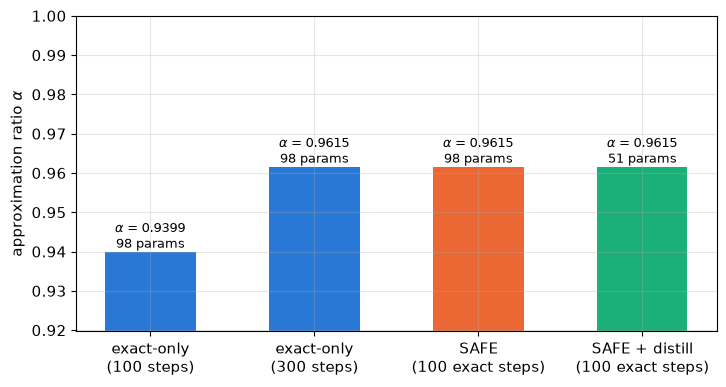

In [10]:
labels = [f"exact-only\n({EXACT_STEPS} steps)", f"exact-only\n({BASE_STEPS} steps)",
          f"SAFE\n({EXACT_STEPS} exact steps)", f"SAFE + distill\n({EXACT_STEPS} exact steps)"]
alphas = [a_base[EXACT_STEPS - 1], a_base[-1], a_safe[-1], a_dist[-1]]
params = [n_params, n_params, n_params, len(active)]
colors = [PALETTE[0], PALETTE[0], PALETTE[1], PALETTE[2]]

fig, ax = plt.subplots(figsize=(7.4, 4.0))
bars = ax.bar(labels, alphas, color=colors, width=0.55)
for b, a, npar in zip(bars, alphas, params):
    ax.annotate(f"$\\alpha$ = {a:.4f}\n{npar} params", (b.get_x() + b.get_width() / 2, a),
                ha="center", va="bottom", fontsize=9)
ax.set_ylim(min(alphas) - 0.02, 1.0)
ax.set_ylabel(r"approximation ratio $\alpha$")
plt.tight_layout()
plt.savefig("figures/fig_SAFE_ma-QAOA_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Takeaways

- **SAFE = LWPP warmup → (distill) → exact finetune.** The surrogate covers most of the
  optimization distance; the exact resource is spent only at the end. What it buys here is
  budget, not a quality level the baseline cannot reach.
- **The surrogate is PADO-Pauli, the reference is a statevector.** The surrogate is
  differentiable in place, so the warmup is ordinary torch training on a sparse program.
- **Distillation compounds it**: the removed angles (fraction printed above) leave a smaller
  parameter space for the fine-tuning stage.
- Scaling up: raise `n` and keep `max_weight` fixed; past n ≈ 20 drop the brute-force optimum
  and the statevector, and use the surrogate-vs-PennyLane check from
  `01_kicked_ising_127q.ipynb` instead.